# Лабораторная работа №2. Задание 1

## Корабли

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris

%matplotlib inline

sns.set_theme(style="whitegrid", palette="colorblind", font="DejaVu Sans")
ships = pd.read_csv("datasets/Cleaned_ships_data.csv")

## 1. Средняя максимальная загрузка и длина судна

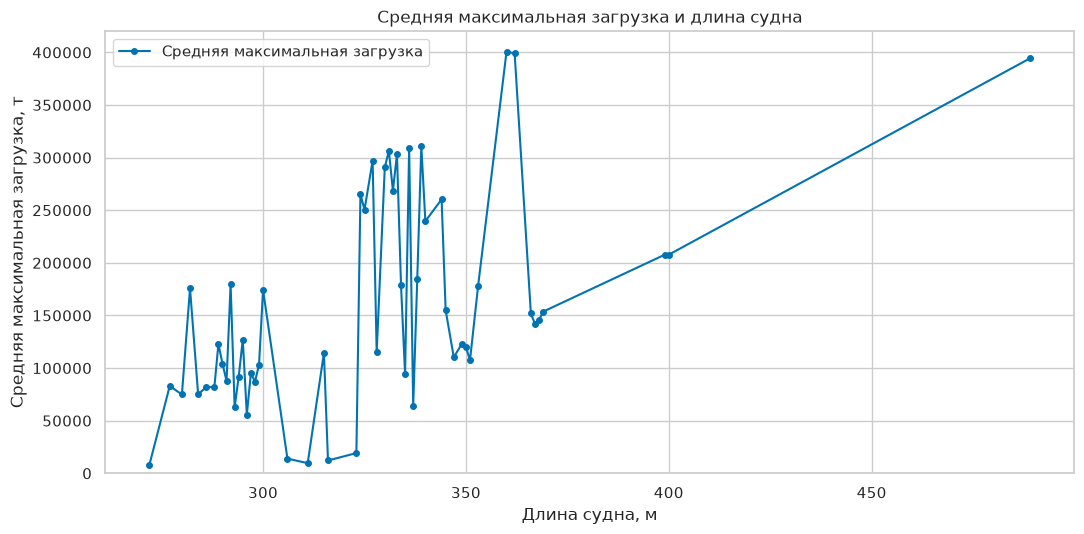

In [2]:
average_load = ships.groupby("length")["dwt"].mean()

plt.figure(figsize=(11, 5.5))
plt.plot(average_load.index, average_load.values, marker="o",
         markersize=4, label="Средняя максимальная загрузка")
plt.title("Средняя максимальная загрузка и длина судна")
plt.xlabel("Длина судна, м")
plt.ylabel("Средняя максимальная загрузка, т")
plt.ylim(bottom=0)
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** для каждой длины рассчитана средняя максимальная загрузка. Она не растёт равномерно с длиной: у судов длиной 333 м среднее составляет около **303 079 т**, а у судов длиной 400 м — около **207 791 т**. В выборке есть суда разных типов, поэтому одной длины недостаточно для оценки загрузки. Линия соединяет рассчитанные средние; для некоторых длин имеется только одно судно.

## 2. Распределение судов по типам

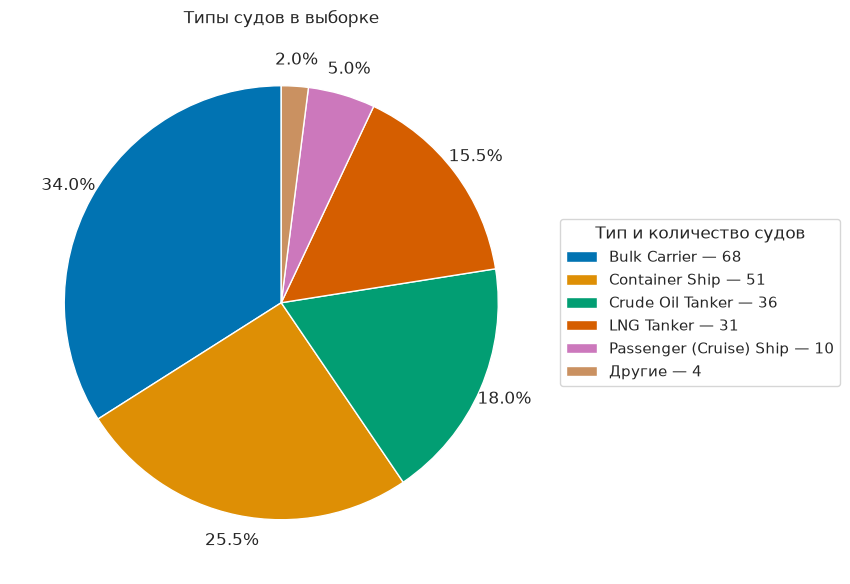

In [3]:
type_counts = ships["ship_name"].value_counts()
rare_count = type_counts[type_counts < 5].sum()
type_counts = type_counts[type_counts >= 5].copy()
if rare_count > 0:
    type_counts["Другие"] = rare_count


labels = []
for name, count in type_counts.items():
    labels.append(f"{name} — {count}")

plt.figure(figsize=(11, 6))
plt.pie(type_counts, autopct="%1.1f%%", startangle=90, pctdistance=1.12)
plt.title("Типы судов в выборке")
plt.legend(labels, title="Тип и количество судов",
           loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

**Вывод:** больше всего балкеров — **68 (34%)**, затем контейнеровозов — **51 (25,5%)**. Вместе они составляют **59,5%** выборки. В «Другие» объединены два редких типа: `FSO` и `Offshore Support Vessel`, по два судна каждого типа. Всего в этой группе **4 судна (2%)**.

## 3. Распределение по годам постройки

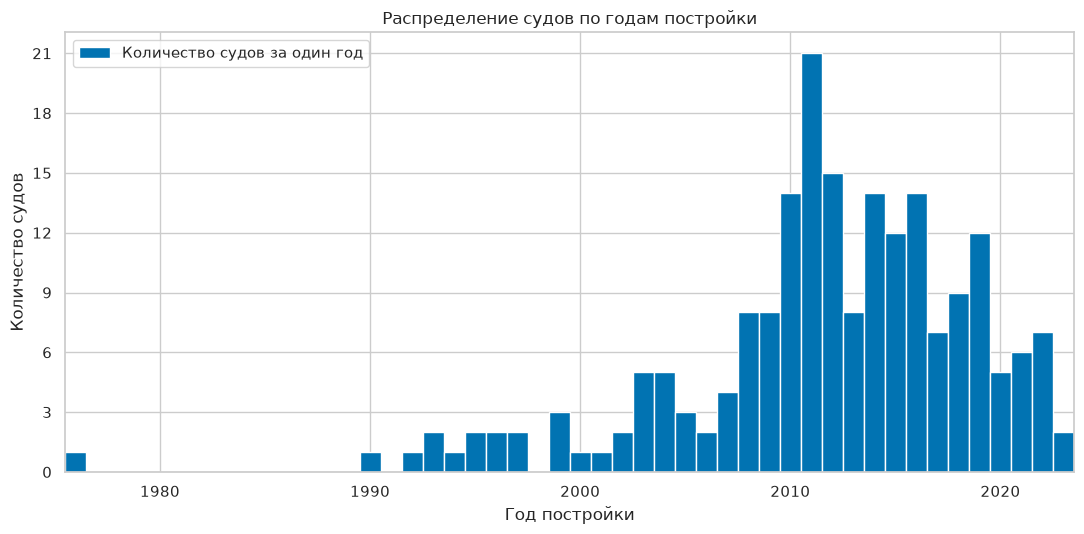

In [4]:
min_year = ships["built_year"].min()
max_year = ships["built_year"].max()
year_bins = np.arange(min_year - 0.5, max_year + 1.5, 1)

plt.figure(figsize=(11, 5.5))
plt.hist(ships["built_year"], bins=year_bins, edgecolor="white",
         label="Количество судов за один год")
plt.title("Распределение судов по годам постройки")
plt.xlabel("Год постройки")
plt.ylabel("Количество судов")
max_count = ships["built_year"].value_counts().max()
plt.yticks(range(0, max_count + 1, 3))
plt.xlim(year_bins[0], year_bins[-1])
plt.legend()
plt.tight_layout()
plt.show()

**Вывод:** чаще всего встречается **2011 год — 21 судно**. В 2000 году и позднее построено **185 из 200 судов (92,5%)**. Таким образом, в выборке преобладают суда, построенные с 2000 года. График описывает выбранные суда, а не мировой выпуск судов по годам.

## 4. Год постройки и максимальная загрузка

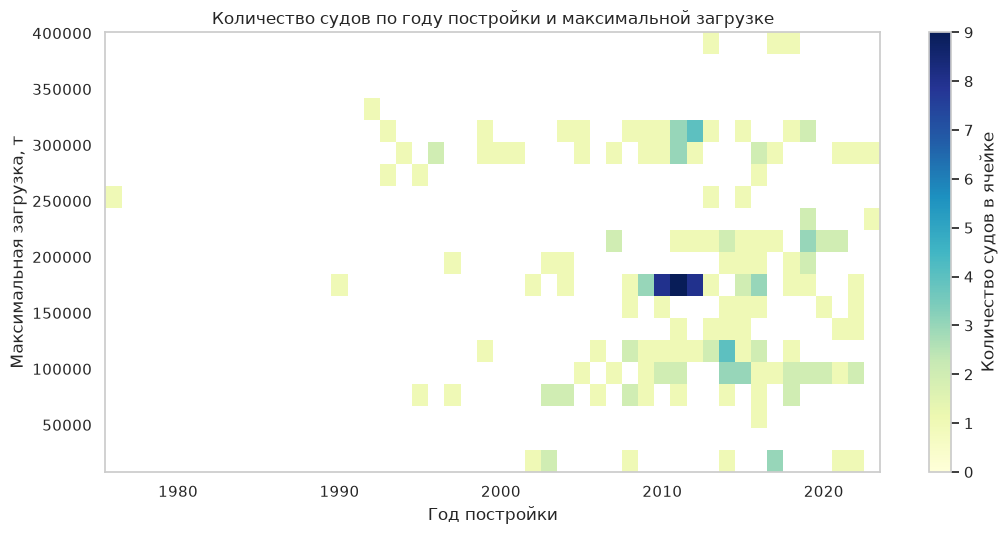

In [5]:
load_bins = np.linspace(ships["dwt"].min(), ships["dwt"].max(), 21)

plt.figure(figsize=(11, 5.5))
plt.hist2d(ships["built_year"], ships["dwt"],
           bins=[year_bins, load_bins], cmap="YlGnBu", cmin=1, vmin=0)
plt.title("Количество судов по году постройки и максимальной загрузке")
plt.xlabel("Год постройки")
plt.ylabel("Максимальная загрузка, т")
plt.colorbar(label="Количество судов в ячейке")
plt.grid(False)
plt.tight_layout()
plt.show()

**Вывод:** цвет показывает количество судов с определённым годом постройки и диапазоном максимальной загрузки. Загрузка разделена на **20 равных интервалов**, для которых заданы **21 граница**. Самая заполненная ячейка — **9 судов 2011 года** с загрузкой от **165 017,6 до 184 657,3 т**. В одном году встречаются суда с разной загрузкой; однозначной зависимости от года постройки не видно. Белые ячейки означают отсутствие судов.

## Ирисы

150 цветов, три вида, четыре характеристики. Все размеры указаны в сантиметрах.

In [6]:
iris_data = load_iris(as_frame=True)
iris = iris_data.data.copy()
iris.columns = [
    "Длина чашелистика", "Ширина чашелистика",
    "Длина лепестка", "Ширина лепестка",
]
iris["Вид"] = iris_data.target.map({
    0: "setosa", 1: "versicolor", 2: "virginica",
})
iris.head()

,Длина чашелистика,Ширина чашелистика,Длина лепестка,Ширина лепестка,Вид
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


### 5. Парная диаграмма

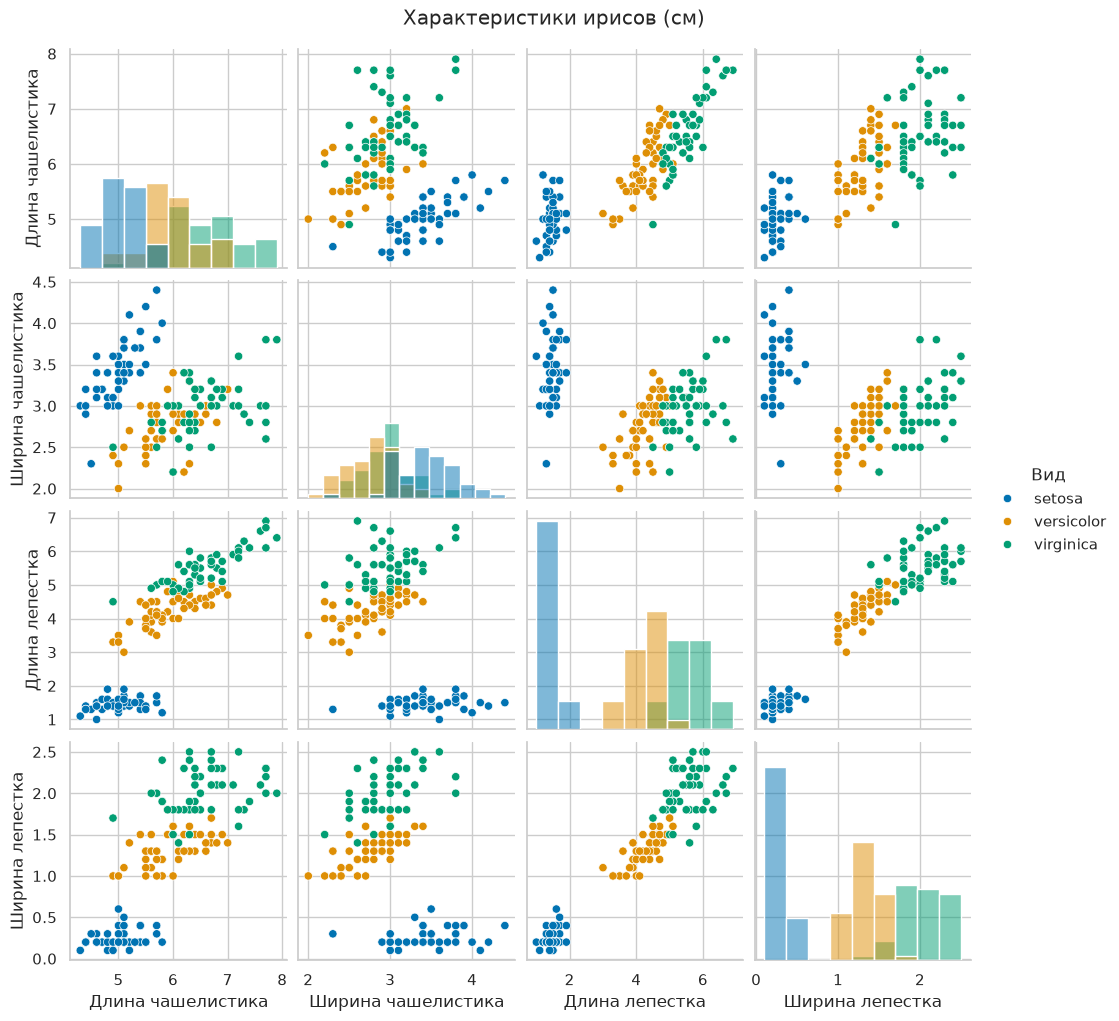

In [7]:
graph = sns.pairplot(iris, hue="Вид", diag_kind="hist")
graph.figure.suptitle("Характеристики ирисов (см)", y=1.02)
plt.show()

**Вывод:** setosa хорошо выделяется по небольшим размерам лепестков. Versicolor и virginica частично пересекаются. По размерам чашелистиков виды различаются менее отчётливо.

### 6. Скрипичная диаграмма

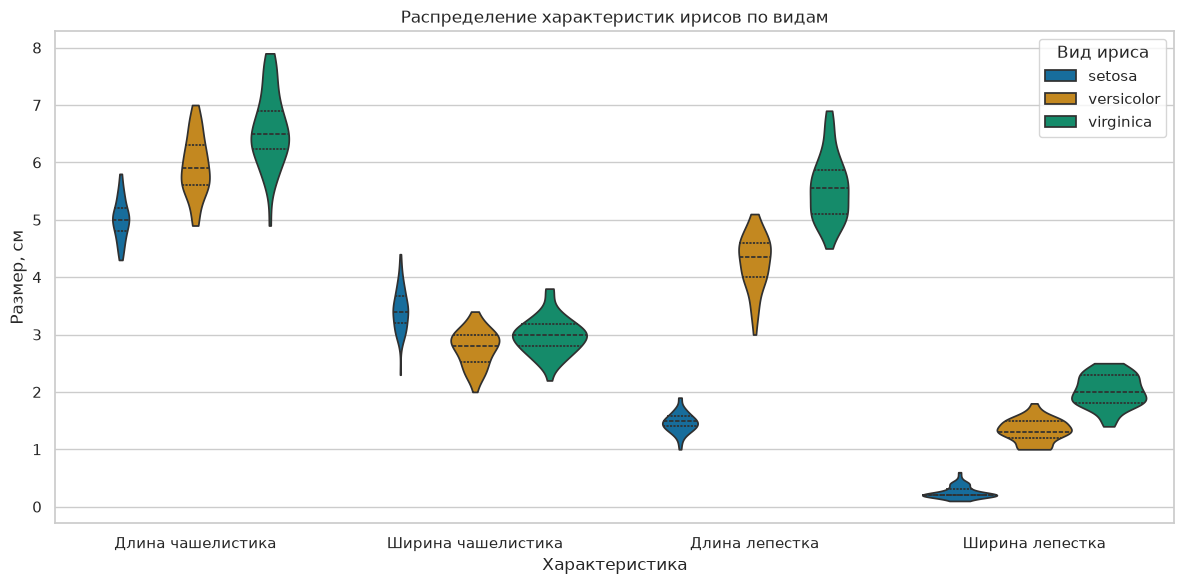

In [8]:
iris_long = iris.melt(
    id_vars="Вид", var_name="Характеристика", value_name="Размер",
)

plt.figure(figsize=(12, 6))
sns.violinplot(data=iris_long, x="Характеристика", y="Размер",
               hue="Вид", inner="quart", cut=0)
plt.title("Распределение характеристик ирисов по видам")
plt.xlabel("Характеристика")
plt.ylabel("Размер, см")
plt.legend(title="Вид ириса")
plt.tight_layout()
plt.show()

**Вывод:** у setosa самые маленькие лепестки, но типичная ширина чашелистика больше, чем у двух других видов. У virginica лепестки обычно крупнее, чем у versicolor. Широкие части скрипок показывают скопления близких значений, внутренние линии — квартили и медиану.